In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from IPython.core.pylabtools import figsize
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("telecom_customer_segments.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Payment_Method
0,TEL-1608,73,Non-binary,34,39.26,6.78,686.0,3,One year,Credit card
1,TEL-1848,79,Non-binary,63,51.47,4.56,821.0,1,Two year,Electronic check
2,TEL-2397,79,Male,60,19.16,1.89,147.0,0,One year,Bank transfer
3,TEL-2186,49,Non-binary,7,27.78,0.73,126.0,0,One year,Credit card
4,TEL-2086,43,Male,53,31.88,2.84,133.0,0,Two year,Bank transfer


In [4]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Tenure_Months         0
Monthly_Bill_GBP      0
Data_Usage_GB         0
Call_Duration_Mins    0
Support_Calls         0
Contract_Type         0
Payment_Method        0
dtype: int64

In [5]:
df.drop("CustomerID",axis=1,inplace=True)

In [6]:
df

,Age,Gender,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Payment_Method
0,73,Non-binary,34,39.26,6.78,686.0,3,One year,Credit card
1,79,Non-binary,63,51.47,4.56,821.0,1,Two year,Electronic check
2,79,Male,60,19.16,1.89,147.0,0,One year,Bank transfer
3,49,Non-binary,7,27.78,0.73,126.0,0,One year,Credit card
4,43,Male,53,31.88,2.84,133.0,0,Two year,Bank transfer
...,...,...,...,...,...,...,...,...,...
1995,19,Non-binary,25,34.64,7.53,687.0,0,Two year,Credit card
1996,72,Male,30,53.94,10.59,418.0,11,Two year,Bank transfer
1997,41,Non-binary,3,41.93,5.26,815.0,0,Two year,Electronic check
1998,65,Non-binary,63,80.85,432.80,64.0,0,One year,Credit card


In [7]:
df.describe()

,Age,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,50.273000,36.97300,47.331755,96.214635,320.944500,1.589500
std,19.427202,20.57598,30.150929,187.702098,336.387061,2.087862
min,18.000000,1.00000,2.000000,-7.300000,-50.000000,0.000000
25%,33.750000,19.00000,26.205000,2.090000,67.000000,0.000000
50%,50.000000,37.00000,41.120000,3.975000,127.500000,1.000000
75%,67.000000,55.00000,63.045000,20.720000,655.500000,2.000000
max,84.000000,72.00000,600.000000,2000.000000,1310.000000,15.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 2000 non-null   int64  
 1   Gender              2000 non-null   object 
 2   Tenure_Months       2000 non-null   int64  
 3   Monthly_Bill_GBP    2000 non-null   float64
 4   Data_Usage_GB       2000 non-null   float64
 5   Call_Duration_Mins  2000 non-null   float64
 6   Support_Calls       2000 non-null   int64  
 7   Contract_Type       2000 non-null   object 
 8   Payment_Method      2000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 140.8+ KB


In [9]:
Max = df["Age"].max()
Min = df["Age"].min()
print(f"The range of age in this data set is between {Min} and {Max}")

The range of age in this data set is between 18 and 84


In [10]:
G_Type = df["Gender"].unique()
print("Below are the gender types in this data set:" , G_Type)


Below are the gender types in this data set: ['Non-binary' 'Male' 'Female']


In [11]:

Max = df["Tenure_Months"].max()
Min = df["Tenure_Months"].min()
print(f"The range of Tenure_Months in this data set is between {Min} and {Max}")

The range of Tenure_Months in this data set is between 1 and 72


In [12]:

Max = df["Data_Usage_GB"].max()
Min = df["Data_Usage_GB"].min()
print(f"The range of Data_Usage_GB in this data set is between {Min} and {Max}")

The range of Data_Usage_GB in this data set is between -7.3 and 2000.0


In [13]:
df[df["Data_Usage_GB"] == -7.3]

,Age,Gender,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Payment_Method
1492,24,Non-binary,34,35.57,-7.3,341.0,13,Two year,Credit card


In [14]:
count=0
for i in df["Data_Usage_GB"]:
    if i < 0:
        print(i)
        count+=1


-0.53
-0.38
-0.68
-1.1
-0.48
-0.4
-0.02
-5.59
-0.43
-5.24
-1.06
-0.92
-3.37
-0.5
-0.21
-0.17
-0.29
-0.46
-7.3
-1.43
-0.17
-1.96
-0.32
-0.68
-0.08
-1.45
-0.59


In [15]:
print(count)

27


In [16]:
count=0
for i in df["Call_Duration_Mins"]:
    if i < 0:
        print(i)
        count+=1
print(count)


-2.0
-7.0
-8.0
-20.0
-2.0
-50.0
6


In [17]:
Pay_Type = df["Payment_Method"].unique()
print("Below are the gender types in this data set:" , Pay_Type)


Below are the gender types in this data set: ['Credit card' 'Electronic check' 'Bank transfer' 'Mailed check']


<Axes: xlabel='Payment_Method', ylabel='Tenure_Months'>

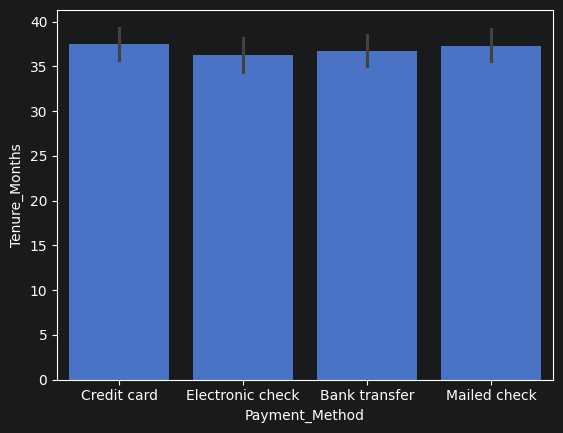

In [18]:
sns.barplot(df,x="Payment_Method",y="Tenure_Months")

<Axes: xlabel='Monthly_Bill_GBP', ylabel='Tenure_Months'>

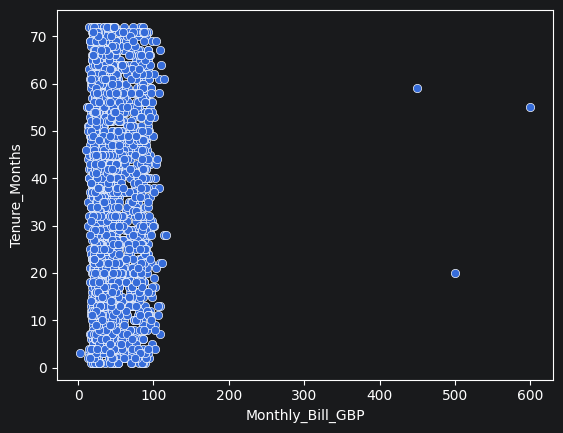

In [19]:
sns.scatterplot(df,x="Monthly_Bill_GBP",y="Tenure_Months")

<Axes: xlabel='Data_Usage_GB', ylabel='Monthly_Bill_GBP'>

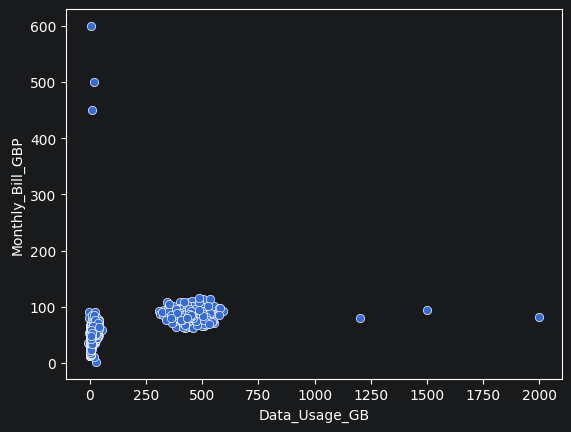

In [20]:
sns.scatterplot(df,x="Data_Usage_GB",y="Monthly_Bill_GBP")

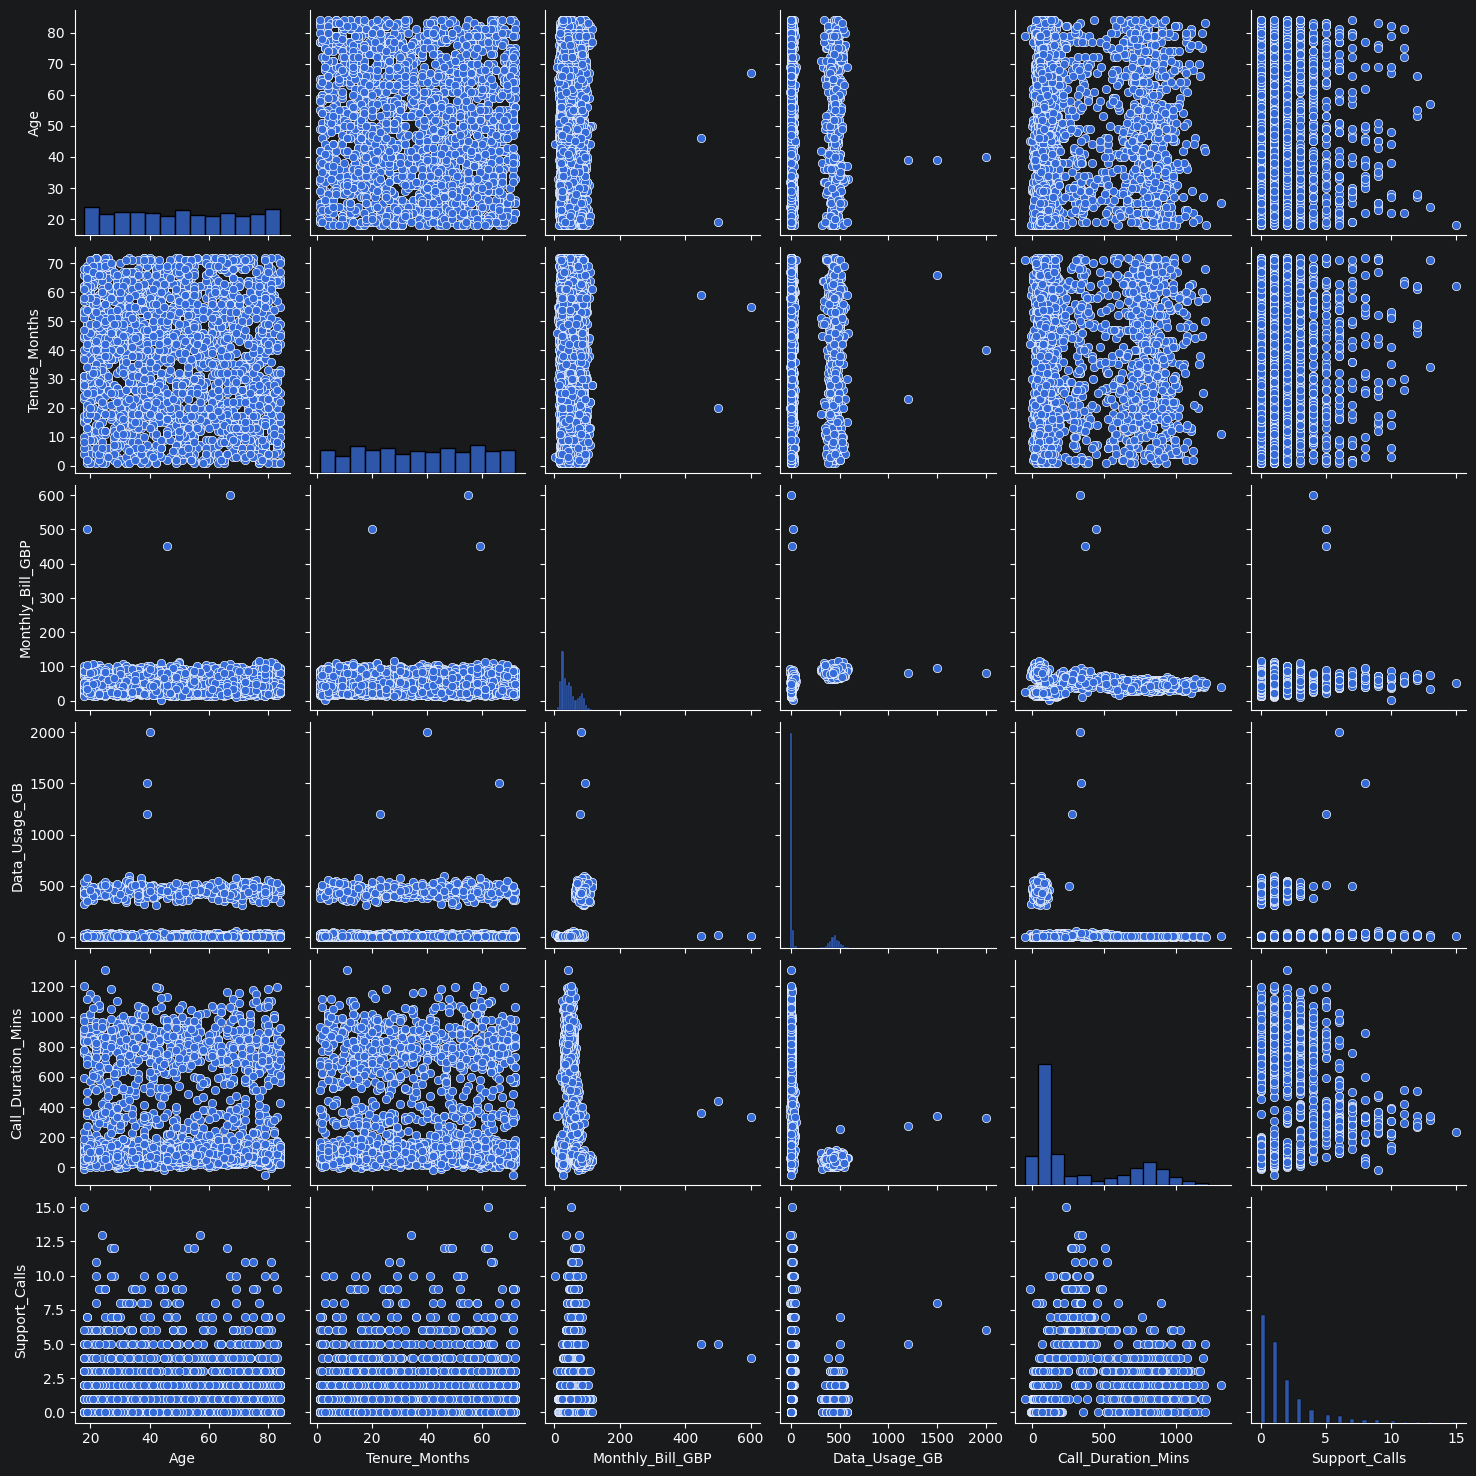

In [21]:
sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Data_Usage_GB'>

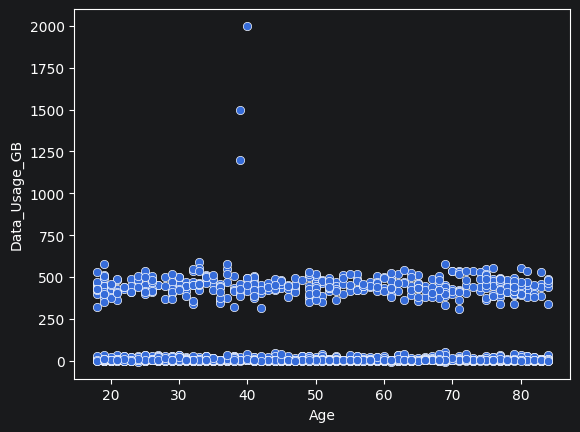

In [22]:
sns.scatterplot(df,x="Age",y="Data_Usage_GB")

In [24]:
from sklearn.preprocessing import OneHotEncoder


# 1. Initialize with sparse_output=False to get a dense numpy array
ohe = OneHotEncoder(sparse_output=False)

# 2. Fit and transform the column
ohe_array = ohe.fit_transform(df[["Gender"]])

# 3. Convert array to a DataFrame with explicit category names
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(["Gender"]))

# 4. Combine it back with your original dataset (and drop the old column)
df = pd.concat([df.drop(columns=["Gender"]), ohe_df], axis=1)


In [25]:
df

,Age,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Payment_Method,Gender_Female,Gender_Male,Gender_Non-binary
0,73,34,39.26,6.78,686.0,3,One year,Credit card,0.0,0.0,1.0
1,79,63,51.47,4.56,821.0,1,Two year,Electronic check,0.0,0.0,1.0
2,79,60,19.16,1.89,147.0,0,One year,Bank transfer,0.0,1.0,0.0
3,49,7,27.78,0.73,126.0,0,One year,Credit card,0.0,0.0,1.0
4,43,53,31.88,2.84,133.0,0,Two year,Bank transfer,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1995,19,25,34.64,7.53,687.0,0,Two year,Credit card,0.0,0.0,1.0
1996,72,30,53.94,10.59,418.0,11,Two year,Bank transfer,0.0,1.0,0.0
1997,41,3,41.93,5.26,815.0,0,Two year,Electronic check,0.0,0.0,1.0
1998,65,63,80.85,432.80,64.0,0,One year,Credit card,0.0,0.0,1.0


In [27]:
# 2. Fit and transform the column
ohe_array = ohe.fit_transform(df[["Payment_Method"]])

# 3. Convert array to a DataFrame with explicit category names
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(["Payment_Method"]))

# 4. Combine it back with your original dataset (and drop the old column)
df = pd.concat([df.drop(columns=["Payment_Method"]), ohe_df], axis=1)



In [28]:
df

,Age,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Gender_Female,Gender_Male,Gender_Non-binary,Payment_Method_Bank transfer,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
0,73,34,39.26,6.78,686.0,3,One year,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,79,63,51.47,4.56,821.0,1,Two year,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,79,60,19.16,1.89,147.0,0,One year,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,49,7,27.78,0.73,126.0,0,One year,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,43,53,31.88,2.84,133.0,0,Two year,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,19,25,34.64,7.53,687.0,0,Two year,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1996,72,30,53.94,10.59,418.0,11,Two year,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1997,41,3,41.93,5.26,815.0,0,Two year,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1998,65,63,80.85,432.80,64.0,0,One year,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Contract_Type"] =le.fit_transform(df["Contract_Type"])

In [30]:
df

,Age,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Gender_Female,Gender_Male,Gender_Non-binary,Payment_Method_Bank transfer,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
0,73,34,39.26,6.78,686.0,3,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,79,63,51.47,4.56,821.0,1,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,79,60,19.16,1.89,147.0,0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,49,7,27.78,0.73,126.0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,43,53,31.88,2.84,133.0,0,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,19,25,34.64,7.53,687.0,0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1996,72,30,53.94,10.59,418.0,11,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1997,41,3,41.93,5.26,815.0,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1998,65,63,80.85,432.80,64.0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0


NameError: name 'figsize' is not defined

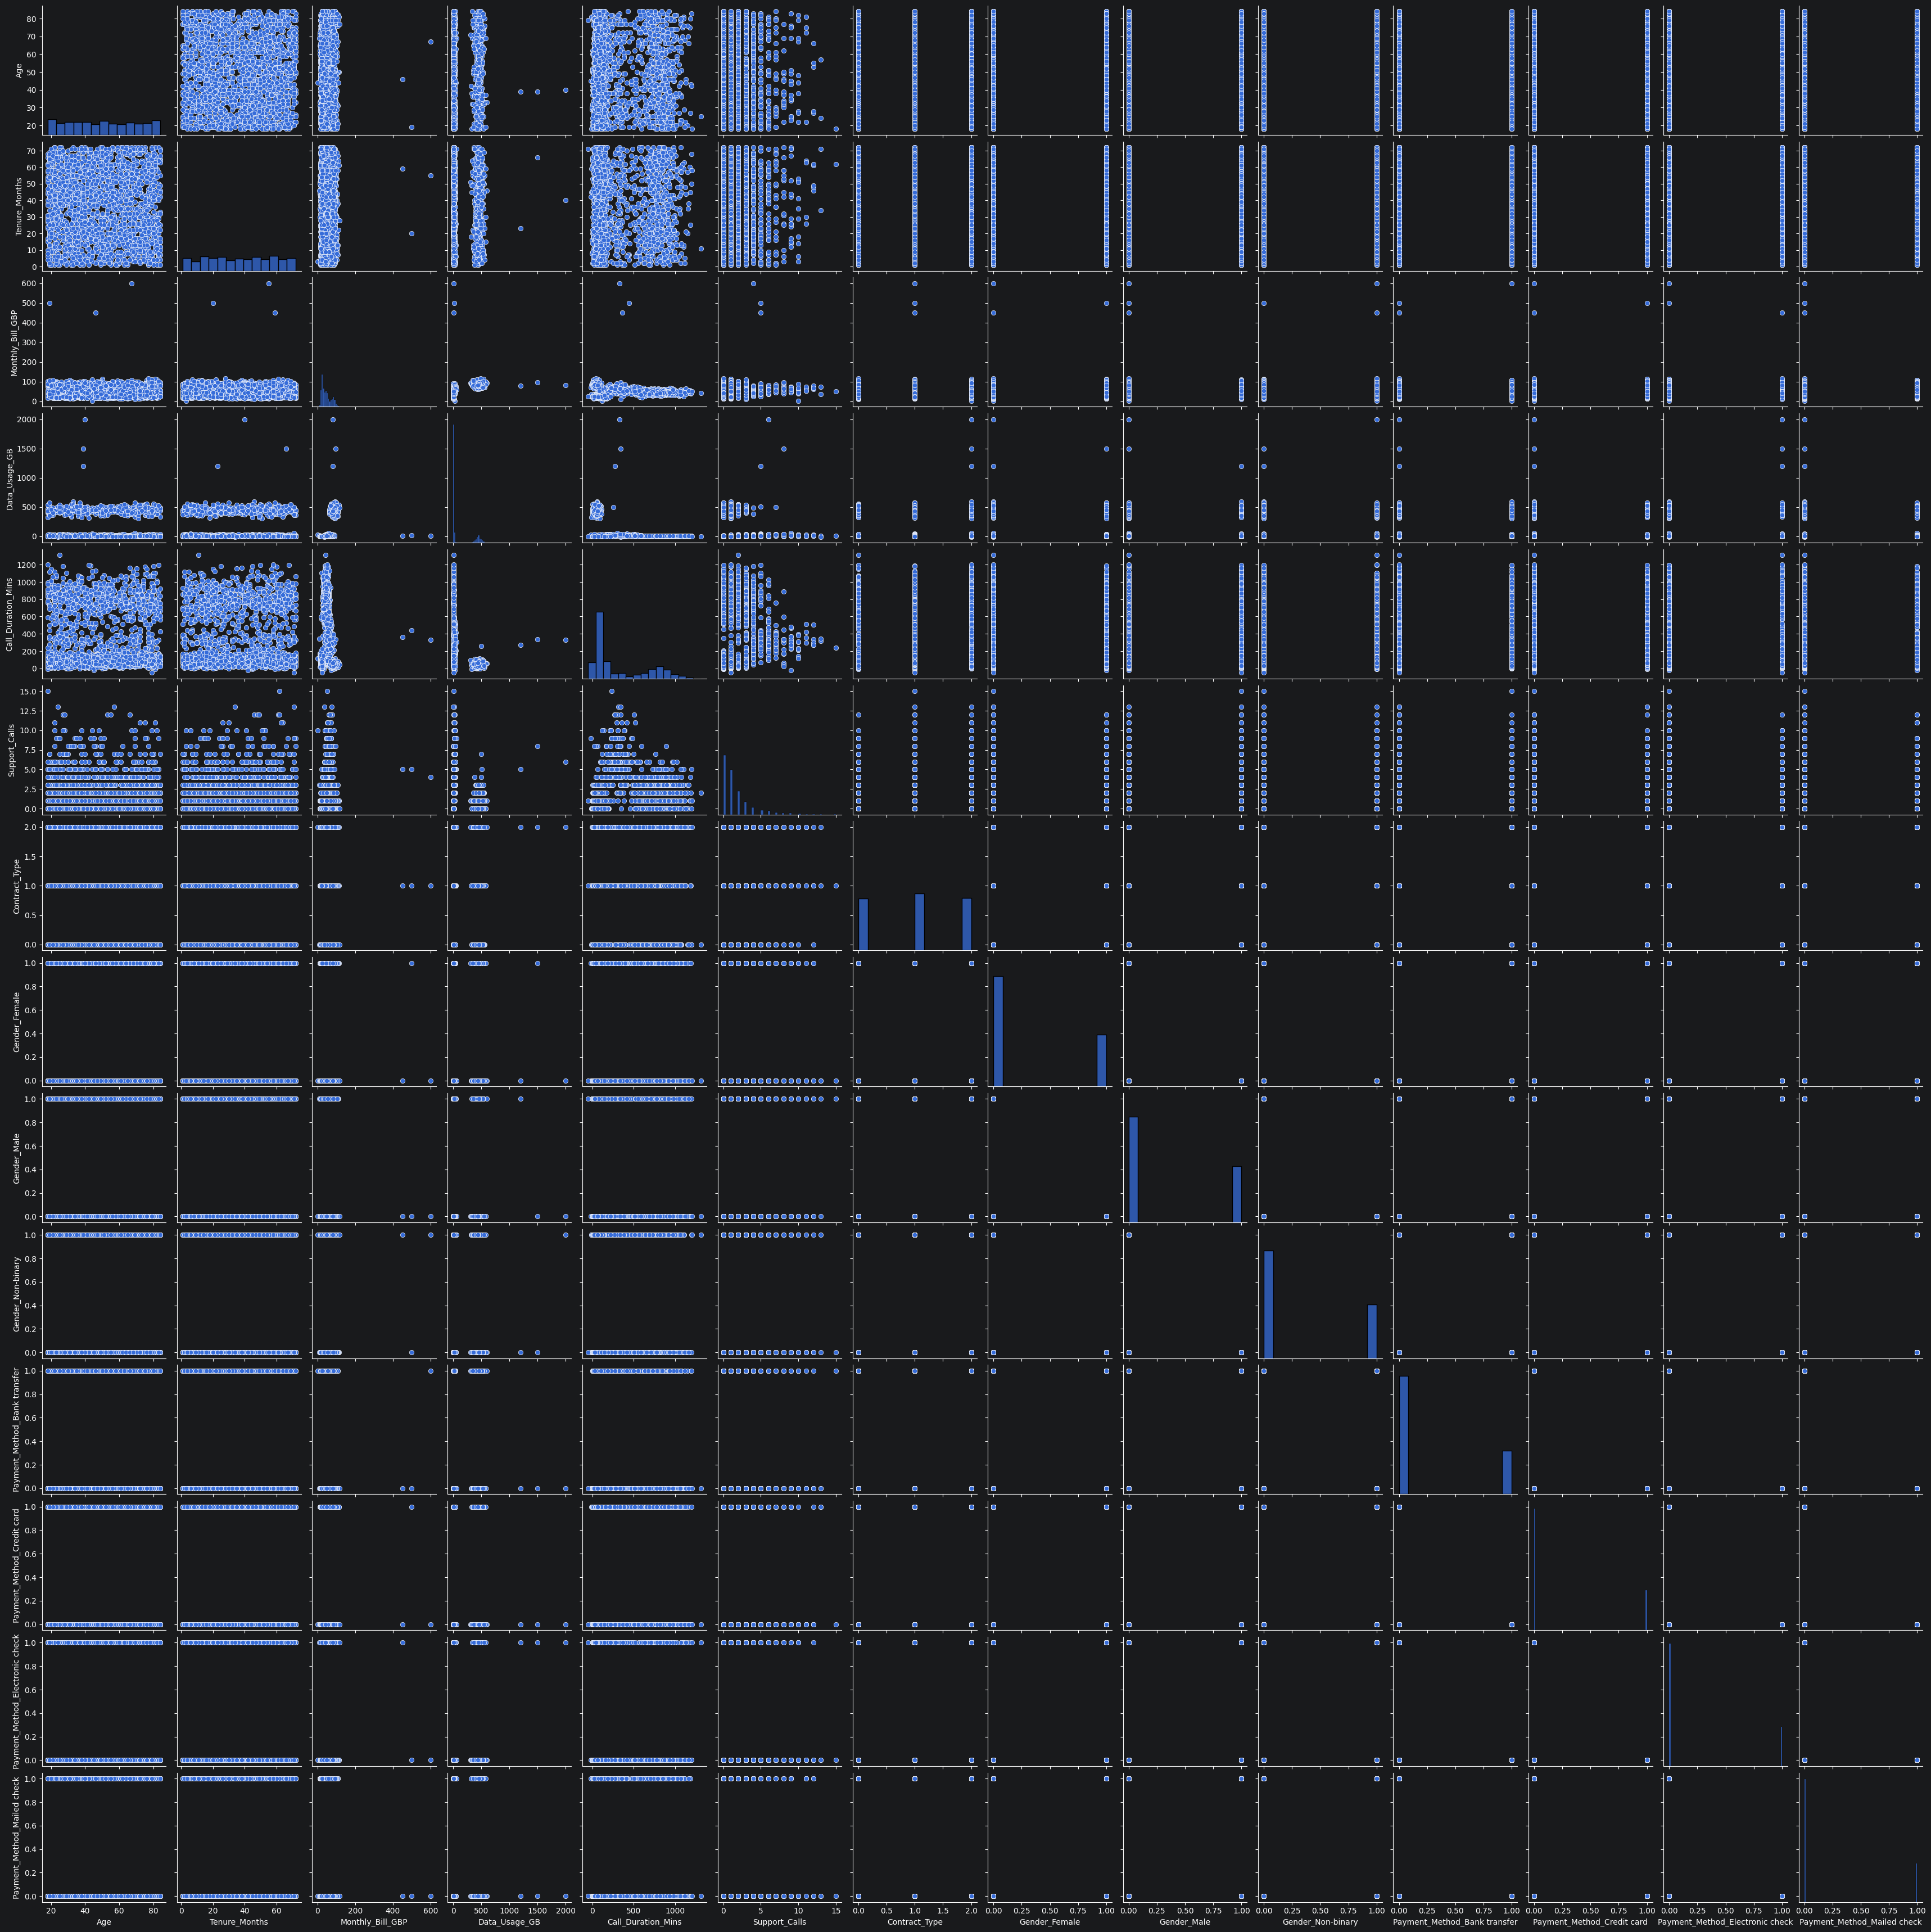

In [32]:
sns.pairplot(df)


In [33]:
# Replace all negative values with 0
numeric_cols = ['Monthly_Bill_GBP', 'Data_Usage_GB', 'Call_Duration_Mins']
df[numeric_cols] = df[numeric_cols].clip(lower=0)

In [34]:
df

,Age,Tenure_Months,Monthly_Bill_GBP,Data_Usage_GB,Call_Duration_Mins,Support_Calls,Contract_Type,Gender_Female,Gender_Male,Gender_Non-binary,Payment_Method_Bank transfer,Payment_Method_Credit card,Payment_Method_Electronic check,Payment_Method_Mailed check
0,73,34,39.26,6.78,686.0,3,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,79,63,51.47,4.56,821.0,1,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,79,60,19.16,1.89,147.0,0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,49,7,27.78,0.73,126.0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,43,53,31.88,2.84,133.0,0,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,19,25,34.64,7.53,687.0,0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1996,72,30,53.94,10.59,418.0,11,2,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1997,41,3,41.93,5.26,815.0,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1998,65,63,80.85,432.80,64.0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [35]:
count=0
for i in df["Call_Duration_Mins"]:
    if i < 0:
        print(i)
        count+=1
print(count)


0


In [39]:
from sklearn.preprocessing import robust_scale
from scipy import stats
stats.probplot(df["Monthly_Bill_GBP"],dist="norm",plot=plt)
plt.show()

AttributeError: module 'matplotlib' has no attribute 'plot'

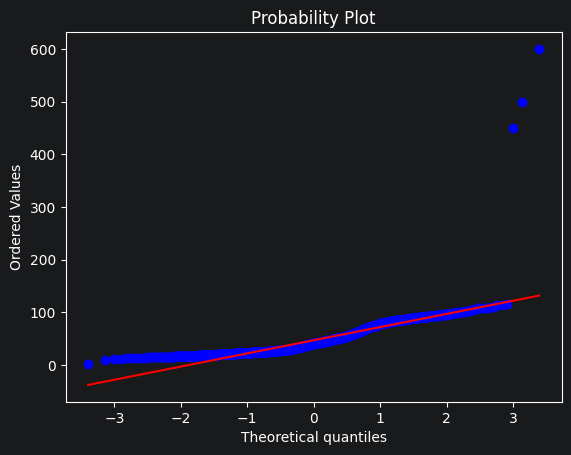

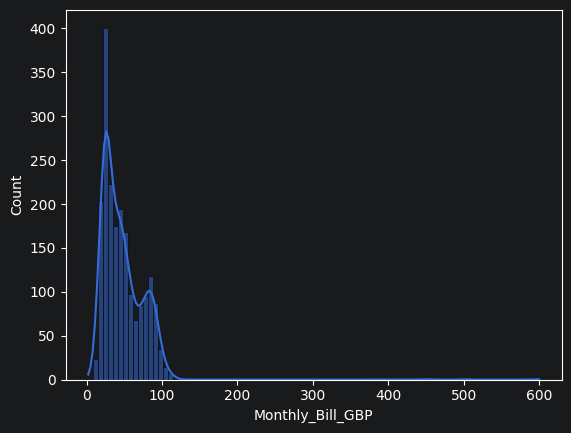

In [44]:
from sklearn.preprocessing import robust_scale
from scipy import stats
import seaborn as sns



sns.histplot(df["Monthly_Bill_GBP"], kde=True)



plt.show()


In [54]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

# 1. Initialize Scaler
scaler = RobustScaler()

# 2. Scale only the numerical features
# (Assuming df_cleaned contains your encoded and cleaned data)
scaled_data = scaler.fit_transform(df)

# 3. Now run DBSCAN
dbscan = DBSCAN(eps=3.5, min_samples=5)
clusters = dbscan.fit_predict(scaled_data)

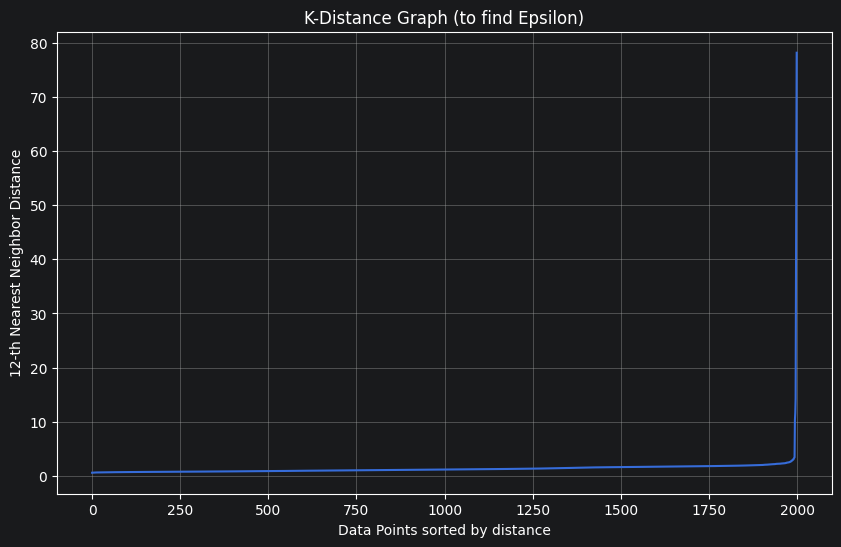

In [55]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. Define k (MinPts). Rule of thumb: 2 * Number of Features
# If you have 6 features after encoding, use k=12
k = 12

# 2. Fit the NearestNeighbors model
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(scaled_data) # Use your RobustScaled data here
distances, indices = neighbors_fit.kneighbors(scaled_data)

# 3. Sort the distances to the k-th neighbor
distances = np.sort(distances[:, k-1], axis=0)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph (to find Epsilon)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()